# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [24]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [25]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [26]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [54]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)
df['has_feature_mods'] = df[[c for c in df.columns if 'feature_' in c]].sum(axis=1) > 0

In [28]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [29]:
phase3_features = get_phase3_features()

In [30]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [31]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [32]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.4229
      Test MAE: 4.71 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.2522
      Test MAE: 14.53 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  -0.4171
      Test MAE: 28.96 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.6706
      Test MAE: 17.21 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.7419
      Test MAE: 43.74 HP

All 5 models trained successfully!


In [33]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
               feature  coefficient
      has_spellcasting    -2.163008
     spellcaster_level     1.834065
    inflicts_petrified    -1.626588
speed_ground_deviation     1.363446
      inflicts_blinded    -1.229730
   speed_fly_deviation     1.108893
    inflicts_paralyzed    -0.997713
  movement_types_count     0.749645
           speed_climb    -0.715474
            speed_swim    -0.683510

CR2 Top Features by Coefficient:
               feature  coefficient
      inflicts_charmed    -7.345327
speed_ground_deviation     5.820293
            speed_swim     5.372883
   vulnerability_count     4.557654
  movement_types_count     4.027377
           speed_climb    -3.568445
   inflicts_frightened    -3.118527
inflicts_incapacitated    -2.816275
     spellcaster_level     2.688836
      has_spellcasting    -2.578923

CR3 Top Features by Coefficient:
                feature  coefficient
       has_spellcasting   -38.760807
      spellcaster_level    27.52

## Investigate Specific Creatures

In [34]:
# df[df['Name'].str.contains('Dragon')].head()

In [56]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# Oni, Unicorn way too penalized for different reasons.
investigate_creature('Elephant', df, contributions_df)

  ELEPHANT (CR 4.0)

Actual HP:              76
Predicted HP:          103
Error:                  27  (  34.9%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 4.0):                               101

PHASE 2: COMBAT STATS
  Feature: ac_deviation                   value:   -2.0  hp impact:      0
  Feature: attack_deviation               value:    2.0  hp impact:      0
  Feature: dpr_deviation                  value:    2.0  hp impact:      0
  Feature: save_dc_deviation              value:   -2.0  hp impact:      0
  Feature: has_advantage_condition        value:    0.0  hp impact:      0
  Feature: has_disadvantage_condition     value:    0.0  hp impact:      0
  Feature: has_attackers_advantage        value:    0.0  hp impact:      0
  Feature: inflicts_prone                 value:    1.0  hp impact:      0
  -----------------------------------------------------
  Phase 2 Total:                              

In [36]:
[c for c in contributions_df.columns if 'feature' in c]

['feature_hp', 'feature_dpr', 'feature_ac', 'feature_attack']

In [37]:
# _df = analysis_dfs['cr3']
# _df.sort_values('predicted_hp')

In [38]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [57]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
        Name    CR  Actual_HP  Predicted_HP     Error
     Cultist 0.125          9      8.999996  0.000004
  Cockatrice 0.500         27     26.999993  0.000007
    Shrieker 0.000         13     12.999746  0.000254
        Wolf 0.250         11     11.013268 -0.013268
    Scorpion 0.000          1      0.936550  0.063450
Giant Badger 0.250         13     12.920919  0.079081
        Hawk 0.000          1      1.089891 -0.089891
     Merfolk 0.125         11     11.138888 -0.138888
   Giant Owl 0.250         19     18.754877  0.245123
    Commoner 0.000          4      3.737295  0.262705

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
    Constrictor Snake 0.25         13      1.998109  11.001891
               Lemure 0.00         13      1.701318  11.298682
               Dretch 0.25         18      6.611309  11.388691
      Swarm of Ravens 0.25         24     12.248727  11.751273
Giant Poisonous Snake 0.25  

In [58]:
_df_check = analysis_dfs['cr2']
_df_check[_df_check['actual_hp'] == 45]


,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile,hp_baseline,ac_baseline,attack_baseline,...,speed_ground_deviation,speed_fly_deviation,has_grapple,has_feature_mods,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
57,Rhinoceros,2.0,45,44.859269,-0.140731,-0.312735,2.020202,54.0,13.0,5.0,...,10.0,0,0,True,45,44.859269,2.0,0.140731,0.140731,0.312735
50,Hunter Shark,2.0,45,41.656515,-3.343485,-7.429966,14.141414,54.0,13.0,5.0,...,-30.0,0,0,True,45,41.656515,2.0,3.343485,3.343485,7.429966
74,Wight,3.0,45,40.012479,-4.987521,-11.083380,26.262626,78.0,13.0,5.0,...,0.0,0,0,True,45,40.012479,3.0,4.987521,4.987521,11.083380
66,Hell Hound,3.0,45,38.861510,-6.138490,-13.641090,33.333333,78.0,13.0,5.0,...,20.0,0,0,True,45,38.861510,3.0,6.138490,6.138490,13.641090
52,Merrow,2.0,45,51.332300,6.332300,14.071779,35.353535,54.0,13.0,5.0,...,-20.0,0,0,True,45,51.332300,2.0,-6.332300,6.332300,-14.071779
41,Centaur,2.0,45,36.920076,-8.079924,-17.955386,40.404040,54.0,13.0,5.0,...,20.0,0,0,True,45,36.920076,2.0,8.079924,8.079924,17.955386
13,Giant Hyena,1.0,45,54.038676,9.038676,20.085947,42.424242,49.5,12.0,5.0,...,20.0,0,0,True,45,54.038676,1.0,-9.038676,9.038676,-20.085947
47,Ochre Jelly,2.0,45,33.518234,-11.481766,-25.515036,53.535354,54.0,13.0,5.0,...,-20.0,0,0,True,45,33.518234,2.0,11.481766,11.481766,25.515036
39,Silver Dragon Wyrmling,2.0,45,13.391830,-31.608170,-70.240379,87.878788,54.0,13.0,5.0,...,0.0,20,0,True,45,13.391830,2.0,31.608170,31.608170,70.240379
87,Ghost,4.0,45,95.102409,50.102409,111.338687,92.929293,100.8,14.0,6.0,...,-30.0,0,0,True,45,95.102409,4.0,-50.102409,50.102409,-111.338687



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


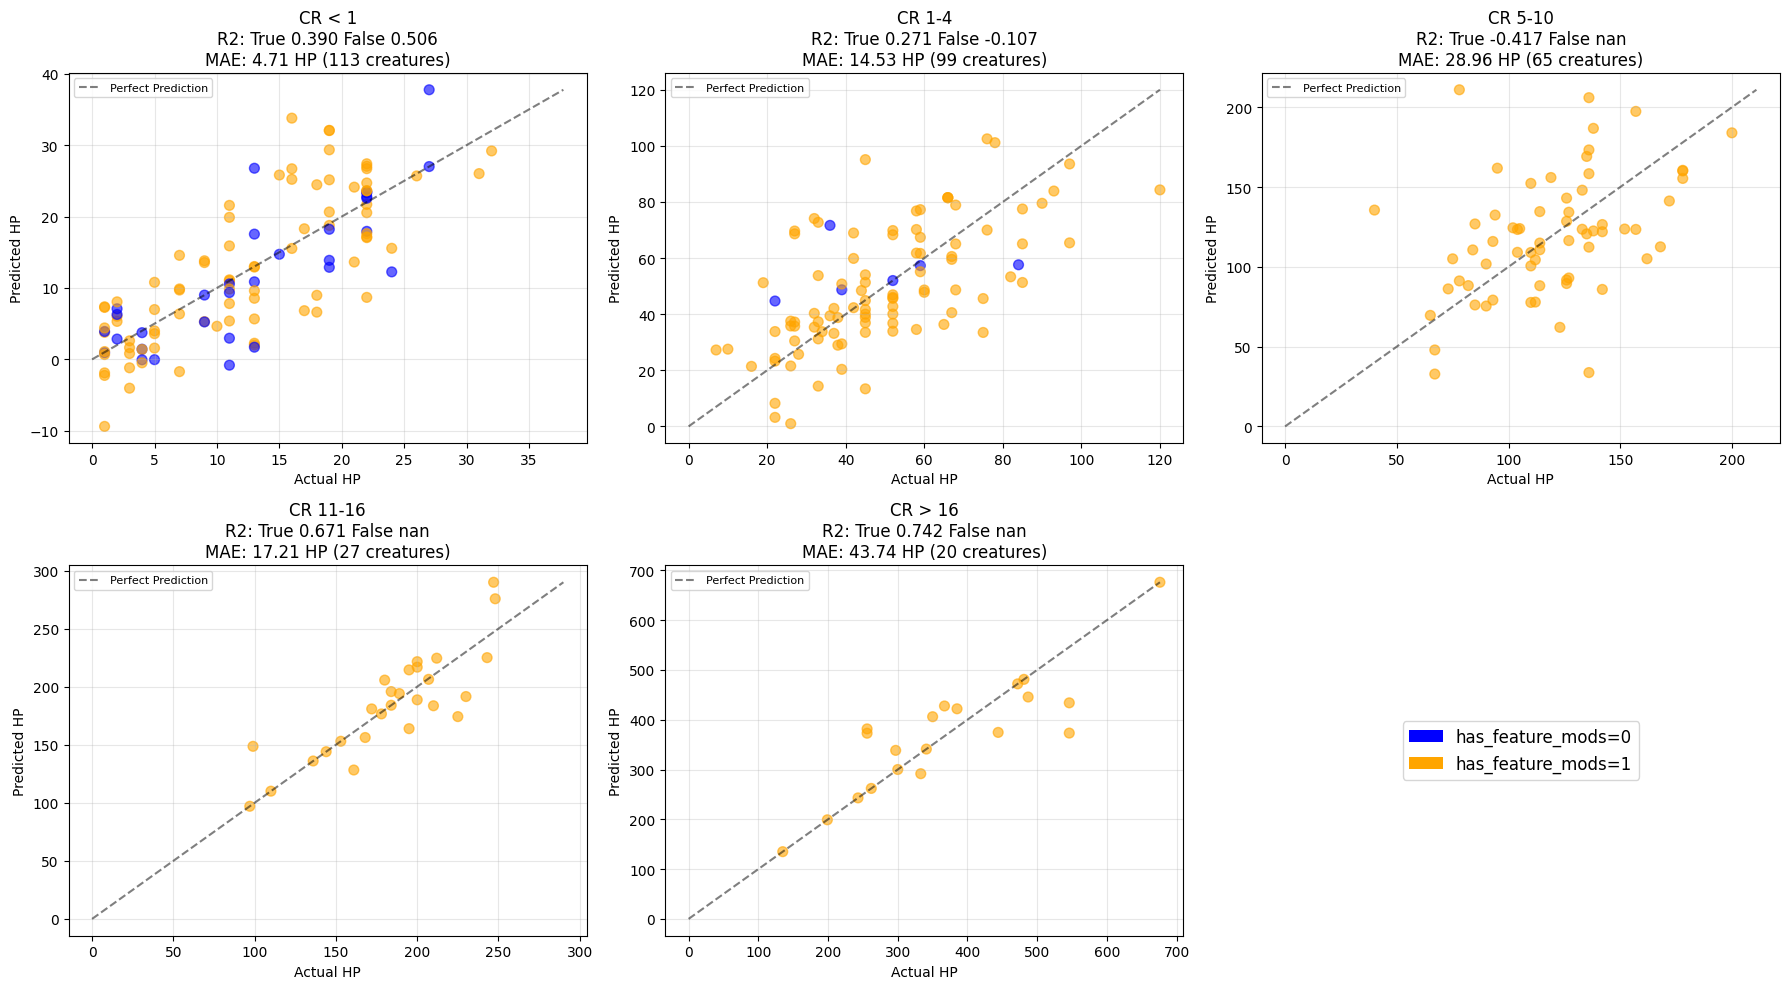

In [60]:

plot_performance_scatter(analysis_dfs, highlight_feature='has_feature_mods')

In [64]:
for k, v in df[df['Name']=='Hill Giant'][[c for c in df.columns if 'feature' in c]].iloc[0].items():
    print(f"{k}: {v}")

feature_dpr: 0.0
feature_ac: 0
feature_attack: 0
feature_hp: 0.0
feature_aggressive: 0
feature_ambusher: 0
feature_amorphous: 0
feature_amphibious: 0
feature_angelic_weapons: 0
feature_antimagic_susceptibility: 0
feature_avoidance: 0
feature_blind_senses: 0
feature_blood_frenzy: 0
feature_breath_weapon: 0
feature_brute: 0
feature_charge: 0
feature_charm: 0
feature_constrict: 0
feature_damage_absorption: 0
feature_damage_transfer: 0
feature_death_burst: 0
feature_devils_sight: 0
feature_dive_attack: 0
feature_echolocation: 0
feature_elemental_body: 0
feature_enlarge: 0
feature_etherealness: 0
feature_false_appearance: 0
feature_fey_ancestry: 0
feature_fiendish_blessing: 0
feature_flyby: 0
feature_frightful_presence: 0
feature_grapple: 0
feature_grappler: 0
feature_hold_breath: 0
feature_horrifying_visage: 0
feature_illumination: 0
feature_immutable_form: 0
feature_incorporeal_movement: 0
feature_innate_spellcasting: 0
feature_invisibility: 0
feature_keen_senses: 0
feature_labyrinthine_r

In [44]:
_df = analysis_dfs['cr3']
_df.sort_values('predicted_hp')

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile,hp_baseline,ac_baseline,attack_baseline,...,inflicts_prone,speed_ground_deviation,speed_fly_deviation,has_grapple,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
23,Unicorn,5.0,67,32.801228,-34.198772,-51.042943,92.307692,114.0,15.0,7.0,...,1,20.0,0,0,67,32.801228,5.0,34.198772,34.198772,51.042943
9,Shambling Mound,5.0,136,33.729523,-102.270477,-75.198880,96.923077,114.0,15.0,7.0,...,0,-10.0,0,1,136,33.729523,5.0,102.270477,102.270477,75.198880
12,Wraith,5.0,67,47.906541,-19.093459,-28.497700,69.230769,114.0,15.0,7.0,...,0,-30.0,0,0,67,47.906541,5.0,19.093459,19.093459,28.497700
26,Drider,6.0,123,62.081147,-60.918853,-49.527523,90.769231,134.4,15.0,7.0,...,0,0.0,0,0,123,62.081147,6.0,60.918853,60.918853,49.527523
1,Half-Red Dragon Veteran,5.0,65,69.585102,4.585102,7.054004,12.307692,114.0,15.0,7.0,...,0,0.0,0,0,65,69.585102,5.0,-4.585102,4.585102,-7.054004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,Cloud Giant,9.0,200,184.005255,-15.994745,-7.997373,16.923077,174.0,16.0,8.0,...,0,10.0,0,0,200,184.005255,9.0,15.994745,15.994745,7.997373
55,Treant,9.0,138,186.810491,48.810491,35.369921,81.538462,174.0,16.0,8.0,...,0,0.0,0,0,138,186.810491,9.0,-48.810491,48.810491,-35.369921
39,Giant Ape,7.0,157,197.430022,40.430022,25.751606,63.076923,156.0,15.0,7.0,...,0,10.0,0,0,157,197.430022,7.0,-40.430022,40.430022,-25.751606
60,Deva,10.0,136,206.032790,70.032790,51.494699,93.846154,186.0,17.0,9.0,...,0,0.0,30,0,136,206.032790,10.0,-70.032790,70.032790,-51.494699



📊 VISUALIZATION: Error Distribution (5 CR Buckets)


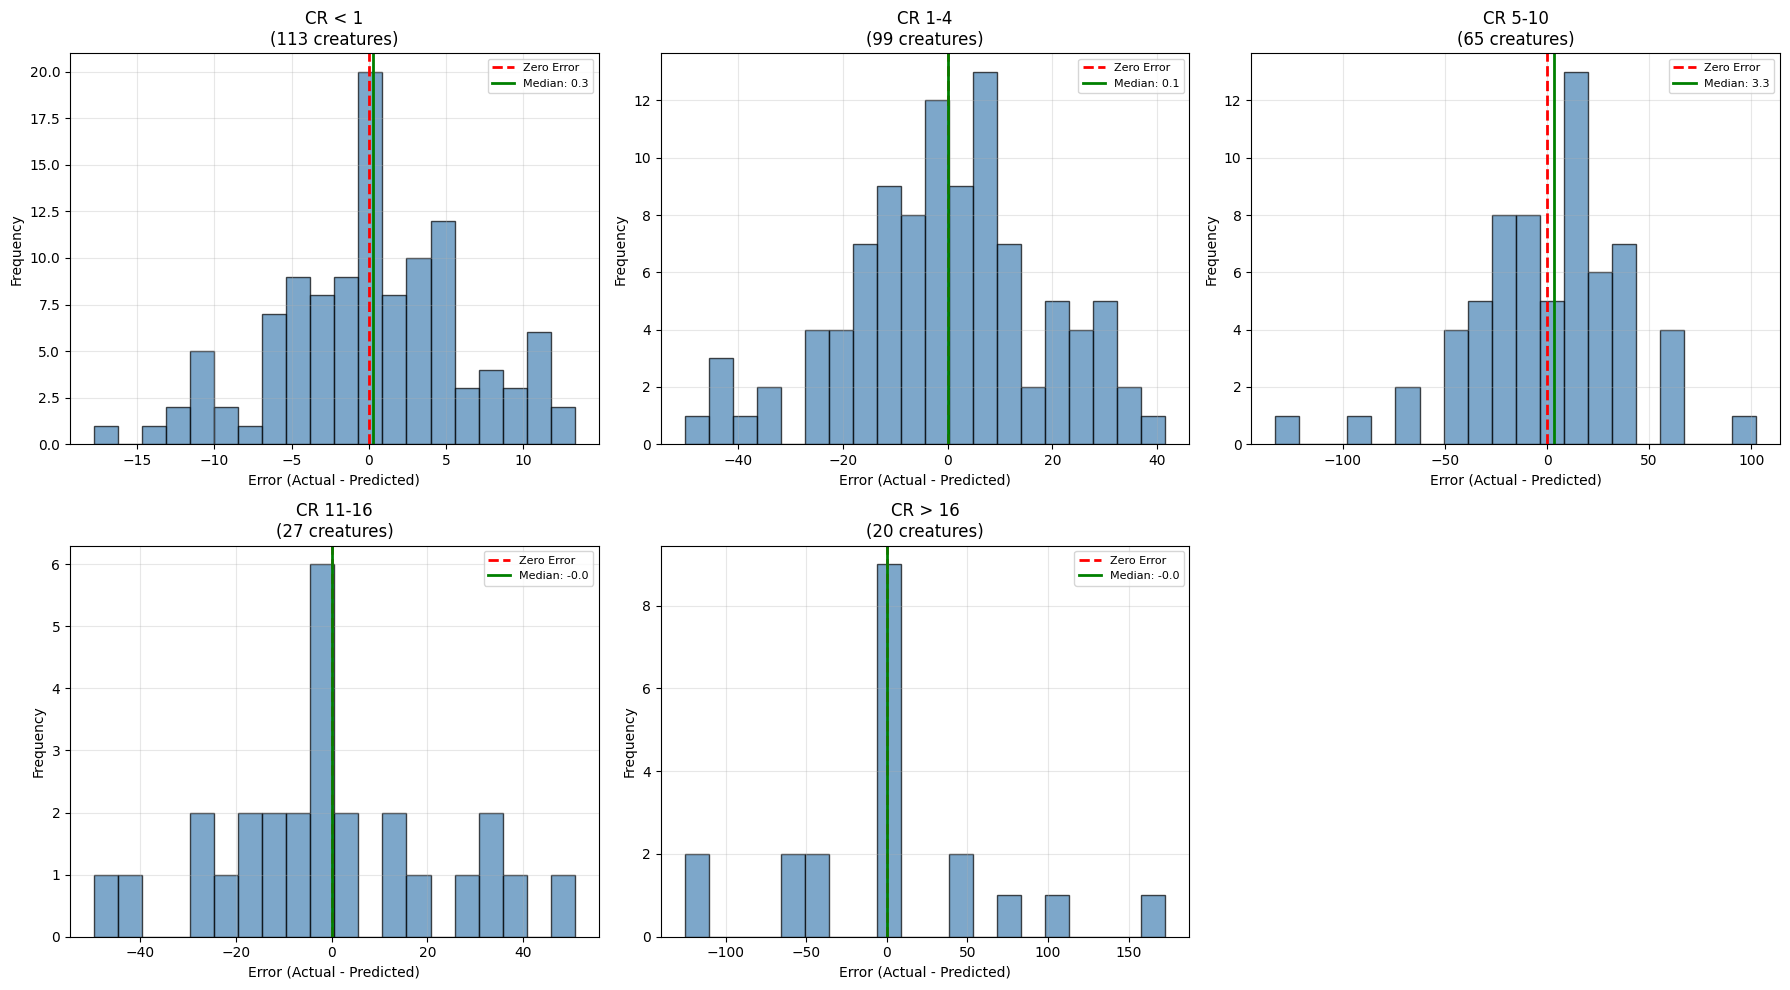

In [45]:
plot_error_hist(analysis_dfs)